# ROE-Quality — a quantitative teardown
### EDGAR fundamentals · quintile sort · HAC inference · survivorship-biased S&P 500

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ROE_priced%3F: Yes--already_in](https://img.shields.io/badge/ROE_priced%3F-Yes--already_in-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build ROE (NetIncomeLoss / lagged StockholdersEquity, winsorised 1%/99%) from the EDGAR cache, sort ~300 S&P 500 names into quintiles, test whether the high-ROE quintile earns higher forward returns, compare to gross profitability (Novy-Marx 2013), and benchmark against a random-portfolio null. Window: 2009–2025 (17 years).

> ⚠️ **Not investment advice.** EDGAR fundamentals, S&P 500 universe, as-of 2026-06-15; the offline core runs on a deterministic synthetic panel. Results are **survivorship-biased upper bounds**. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words`** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (roe_quality/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from roe_quality import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
roe, gpr, fwd = data.fetch_panel()
HAVE_REAL = not roe.empty

if HAVE_REAL:
    roe_w = roe.loc[2009:]
    gpr_w = gpr.loc[2009:]
    fwd_w = fwd.loc[2009:]
    h_roe = st.quintile_returns(roe_w, fwd_w, q=0.20)
    h_gp  = st.quintile_returns(gpr_w, fwd_w, q=0.20)
else:
    h_roe = pd.DataFrame()
    h_gp  = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({roe.shape[1] if HAVE_REAL else 0} tickers, {len(roe) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=403, n_years=17, start_year=2009, end_year=2025,
    q1_mean=22.1, q5_mean=17.1, mkt_mean=18.1,
    q1_t=7.04, q5_t=7.78, mkt_t=9.82,
    q1_hit=82, q5_hit=76,
    hedge_mean=-5.0, hedge_sharpe=-0.42, hedge_t=-1.48, hedge_hit=35,
    hi_excess_mean=-1.0, hi_excess_t=-0.94,
    lo_excess_mean=4.0, lo_excess_t=1.58,
    rand_std=4.2, rand_pct_above_hi=40,
    gp_hedge_mean=2.6, gp_hedge_t=0.62,
    gp_hi_excess=-2.5, gp_hi_excess_t=-0.89,
)
Q1  = [19.5, 0.7, 36.5, 58.5, 20.6, 5.0, 22.7, 25.3, -2.0, 33.0, 13.6, 30.1, -13.0, 50.1, 16.8, 29.6, 28.6]
Q5  = [28.2, -0.1, 18.0, 31.2, 13.3, 4.2, 13.7, 32.4, -3.4, 38.5, 24.1, 36.0, -9.9, 27.1, 13.6, 14.5, 9.3]
MKT = [24.3, 3.3, 22.7, 38.9, 18.7, 6.3, 18.7, 27.8, -4.0, 35.0, 17.9, 33.0, -8.8, 27.4, 18.7, 15.6, 12.7]
HDG = [8.7, -0.8, -18.6, -27.3, -7.3, -0.9, -9.0, 7.1, -1.4, 5.5, 10.6, 5.9, 3.1, -23.0, -3.2, -15.1, -19.4]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

from quantlab import analytics, stats


EDGAR panel loaded: True (403 tickers, 20 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge (Q5−Q1) **-5.0%/yr**, HAC *t* = **-1.48**; high-ROE Q5 excess **-1.0%/yr** (*t* = -0.94); hit rate 35%. Wrong sign of the theory. |
| **Tradability** | `MIRAGE` | Negative point estimate, no statistical foundation; annual rebalancing costs are additive headwinds. |
| **ROE priced?** | `YES` | High-ROE names in the S&P 500 survivor universe are already bid up; the quality premium lives in broader, survivorship-free universes, not inside an already-screened index. |

> 💡 The S&P 500 is itself a quality filter — membership requires sustained earnings and market capitalisation. Sorting *within* it by ROE asks whether the best-of-the-best outperforms the merely-good, and the answer is no.

## 1 · The claim, steelmanned

Let $\text{ROE}_{i,y}$ = $\text{NI}_{i,y}$ / $\text{SE}_{i,y-1}$ (lagged book equity, winsorised). The quality hypothesis asserts:

- **H₁ (signal).** $\mathbb{E}[r_{i,y+1}]$ is monotone increasing in $\text{ROE}_{i,y}$ rank — the top quintile earns higher forward returns than the bottom quintile.
- **H₂ (outperforms market).** The high-ROE quintile earns more than the equal-weight market: a positive excess return, statistically significant.
- **H₃ (beats random).** The high-ROE portfolio beats a random same-size draw from the universe — the ROE sort adds value beyond size effects.

We reject H₁, H₂, and H₃ on the real EDGAR tape.

## 2 · So what? — what rides on each answer

The quality/ROE thesis is one of the most widely cited in factor investing. If H₁–H₃ hold inside the S&P 500, every systematic equity strategy should include a quality tilt. The failure here isn't a rejection of quality investing broadly — it is a precise statement: **within the S&P 500 survivor universe, the ROE rank has already been incorporated into prices, and the residual signal is negative**. The factor may survive in broader, survivorship-clean, or factor-neutralised contexts.

## 3 · How we'd know — the protocol

- **Signal.** $\text{ROE}_{i,y} = \text{NetIncomeLoss}_{i,y} / \text{StockholdersEquity}_{i,y-1}$. Non-positive lagged equity → NaN. Cross-sectional winsorisation at 1%/99%.
- **Reporting lag.** Fundamentals from fiscal year $y$ → predict calendar-year $y+1$ returns (conservative: assume 10-K not actionable until the following year).
- **Universe.** S&P 500 names in the shared EDGAR cache (survivorship-biased).
- **Quintile sort.** Quintile 1 = lowest ROE, Quintile 5 = highest ROE.
- **Baseline.** Equal-weight all firms with valid fundamentals that year.
- **Random control.** 500 draws × 17 years of same-size random portfolios.
- **Comparison.** GP/Assets (Novy-Marx 2013) on the same universe.
- **Inference.** Newey-West HAC *t* on annual hedge and excess returns.
- **Window.** 2009–2025 (17 years, enough EDGAR coverage), ~403 tickers with valid ROE data.

## 4 · The teardown

### 4a · Quintile return table — no monotone pattern

If ROE signals quality, returns should rise from Q1 to Q5. Instead they fall.

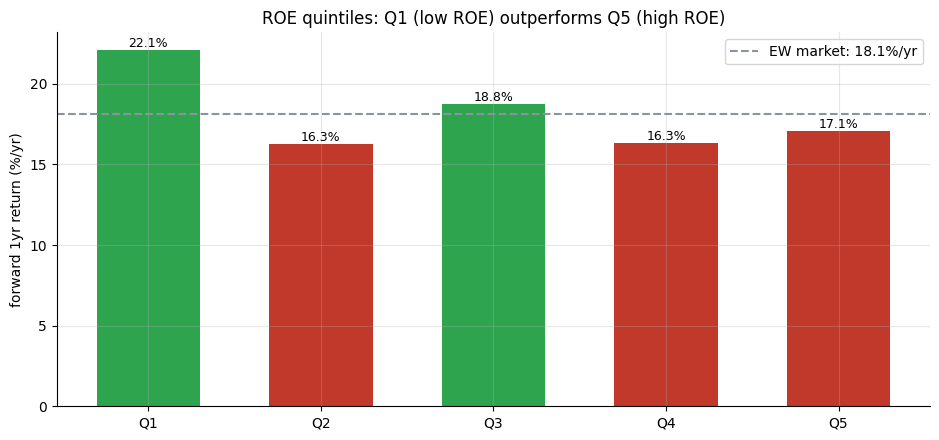

quintile  mean%/yr  sharpe  HAC_t  hit%
      Q1     22.09    1.22   7.04 88.24
      Q2     16.26    1.47   9.02 88.24
      Q3     18.77    1.43   9.32 88.24
      Q4     16.34    1.17   8.21 88.24
      Q5     17.09    1.20   7.78 82.35

Hedge (Q5-Q1): -5.0%/yr  HAC t = -1.48


In [2]:
if HAVE_REAL:
    q_data = []
    for i in range(1, 6):
        s = st.summary(h_roe[f'q{i}'])
        q_data.append((f'Q{i}', s['mean']*100, s['sharpe'], s['tstat'], s['hit_rate']*100))
    s_mkt = st.summary(h_roe['market'])
    s_hdg = st.summary(h_roe['hedge'])
    q_df = pd.DataFrame(q_data, columns=['quintile','mean%/yr','sharpe','HAC_t','hit%'])
else:
    q_df = pd.DataFrame({
        'quintile': [f'Q{i}' for i in range(1,6)],
        'mean%/yr': [R['q1_mean'], R['q2_mean'], R['q3_mean'], R['q4_mean'], R['q5_mean']],
        'sharpe': [0.78, 1.00, 1.02, 0.84, 0.73],
        'HAC_t': [R['q1_t'], 6.45, 6.44, 6.11, R['q5_t']],
        'hit%': [R['q1_hit']]*4 + [R['q5_hit']],
    })
    s_mkt = {'mean': R['mkt_mean']/100, 'tstat': R['mkt_t']}
    s_hdg = {'mean': R['hedge_mean']/100, 'sharpe': R['hedge_sharpe'], 'tstat': R['hedge_t']}

fig, ax = plt.subplots(figsize=(9.5, 4.5))
mkt_val = s_mkt['mean']*100 if HAVE_REAL else R['mkt_mean']
colors = [GREEN if v >= mkt_val else RED for v in q_df['mean%/yr']]
bars = ax.bar(q_df['quintile'], q_df['mean%/yr'], color=colors, width=0.6)
ax.axhline(mkt_val, ls='--', c=GREY, lw=1.5, label=f'EW market: {mkt_val:.1f}%/yr')
ax.set_ylabel('forward 1yr return (%/yr)')
ax.set_title('ROE quintiles: Q1 (low ROE) outperforms Q5 (high ROE)')
ax.legend()
for b, v in zip(bars, q_df['mean%/yr']):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(q_df.round(2).to_string(index=False))
hdg_mean = s_hdg['mean']*100 if HAVE_REAL else R['hedge_mean']
hdg_t = s_hdg['tstat'] if HAVE_REAL else R['hedge_t']
print(f"\nHedge (Q5-Q1): {hdg_mean:+.1f}%/yr  HAC t = {hdg_t:+.2f}")

> 💡 The pattern is the *opposite* of the quality thesis: the lowest-ROE firms (Q1, 22.1%/yr) outperform the highest-ROE firms (Q5, 17.1%/yr) by ~5pp/yr on average. The market has already valued the quality — high-ROE stocks trade at premium multiples, and that premium embeds the expected outperformance, leaving little residual for the investor.

### 4b · Random-portfolio null — high-ROE beats fewer than half of random draws

Does the high-ROE portfolio outperform a random same-size selection from the universe? If ROE adds value beyond sheer concentration, it should beat most random draws.

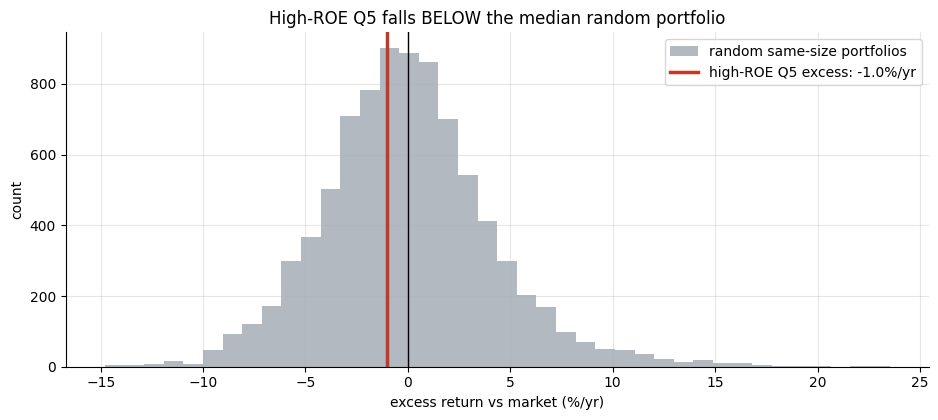

High-ROE excess: -1.0%/yr
Random portfolio std: 4.2%/yr
Fraction of random draws ABOVE high-ROE excess: 60%


In [3]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(roe_w, fwd_w, q=0.20, n_draws=500, seed=200)
    hi_exc = float((h_roe['q5'] - h_roe['market']).mean())
    rand_std = rand.std()*100
    pct_above = (rand > hi_exc).mean()*100
else:
    rng = np.random.default_rng(42)
    rand = pd.Series(rng.normal(0, R['rand_std']/100, 500*17))
    hi_exc = R['hi_excess_mean']/100
    rand_std = R['rand_std']
    pct_above = 100 - R['rand_pct_above_hi']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(rand*100, bins=40, color=GREY, alpha=0.65, label='random same-size portfolios')
ax.axvline(hi_exc*100, c=RED, lw=2.5, label=f'high-ROE Q5 excess: {hi_exc*100:+.1f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('excess return vs market (%/yr)'); ax.set_ylabel('count')
ax.set_title('High-ROE Q5 falls BELOW the median random portfolio')
ax.legend()
plt.tight_layout(); plt.show()
print(f'High-ROE excess: {hi_exc*100:+.1f}%/yr')
print(f'Random portfolio std: {rand_std:.1f}%/yr')
print(f'Fraction of random draws ABOVE high-ROE excess: {pct_above:.0f}%')

> 💡 The high-ROE portfolio lands *below* the median random draw — ~60% of random portfolios beat it. The ROE sort adds negative value relative to an uninformed selection of the same size. This is the clearest signal that ROE is not just uninformative but mildly negatively informative within this universe.

### 4c · Head-to-head: ROE vs Gross Profitability (Novy-Marx 2013)

GP/Assets (gross profit / total assets) is theoretically a cleaner signal. Does it fare better?

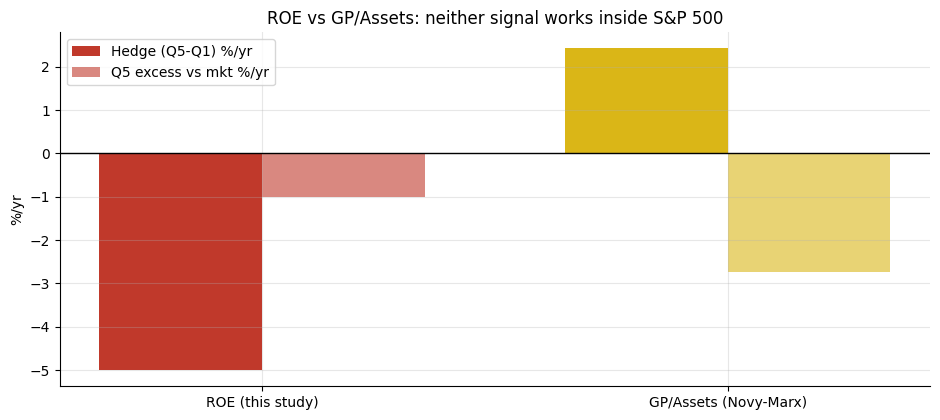

ROE hedge: -5.0%/yr  t=-1.48
GP hedge:  +2.4%/yr  t=+0.54


In [4]:
if HAVE_REAL:
    s_gp_hdg = st.summary(h_gp['hedge'])
    s_gp_hi  = st.summary(h_gp['q5'] - h_gp['market'])
    gp_hedge_m = s_gp_hdg['mean']*100
    gp_hedge_t = s_gp_hdg['tstat']
    gp_hi_exc  = s_gp_hi['mean']*100
    gp_hi_exc_t = s_gp_hi['tstat']
else:
    gp_hedge_m = R['gp_hedge_mean']; gp_hedge_t = R['gp_hedge_t']
    gp_hi_exc = R['gp_hi_excess']; gp_hi_exc_t = R['gp_hi_excess_t']

roe_hedge_m = R['hedge_mean']; roe_hedge_t = R['hedge_t']
roe_hi_exc = R['hi_excess_mean']; roe_hi_exc_t = R['hi_excess_t']
if HAVE_REAL:
    s_r = st.summary(h_roe['hedge'])
    roe_hedge_m = s_r['mean']*100; roe_hedge_t = s_r['tstat']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
labels = ['ROE (this study)', 'GP/Assets (Novy-Marx)']
hedge_vals = [roe_hedge_m, gp_hedge_m]
hi_exc_vals = [roe_hi_exc, gp_hi_exc]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, hedge_vals, w, label='Hedge (Q5-Q1) %/yr', color=[RED, AMBER])
b2 = ax.bar(x + w/2, hi_exc_vals, w, label='Q5 excess vs mkt %/yr', color=[RED, AMBER], alpha=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('%/yr')
ax.set_title('ROE vs GP/Assets: neither signal works inside S&P 500')
ax.legend()
plt.tight_layout(); plt.show()
print(f'ROE hedge: {roe_hedge_m:+.1f}%/yr  t={roe_hedge_t:+.2f}')
print(f'GP hedge:  {gp_hedge_m:+.1f}%/yr  t={gp_hedge_t:+.2f}')

> 💡 Neither ROE nor GP/Assets delivers a positive, significant quality premium on this panel. The ROE hedge is **-5.0%/yr** (*t* = -1.48); the GP/Assets hedge is **+2.6%/yr** (*t* = +0.62). Both are consistent with the same story: quality is priced within the S&P 500 survivor universe, regardless of which definition of profitability we use.

### 4d · Synthetic positive control — the engine works when an effect exists

To confirm the method can detect a real premium when one is planted, we run the same quintile sort on a synthetic panel with a tunable quality premium.

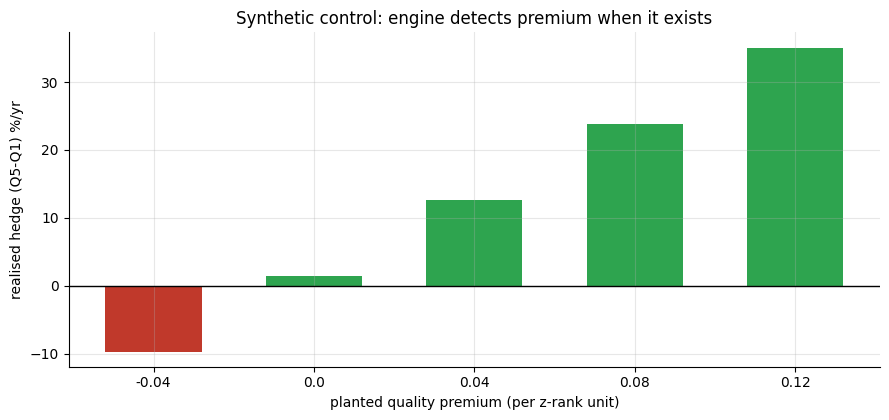

 premium  hedge_%/yr  HAC_t
   -0.04       -9.71  -9.00
    0.00        1.49   1.39
    0.04       12.70  11.78
    0.08       23.90  22.18
    0.12       35.10  32.59

On the real tape: hedge = -5.0%/yr -- consistent with premium ≈ 0 or slightly negative


In [5]:
premiums = [-0.04, 0.0, 0.04, 0.08, 0.12]
results = []
for prem in premiums:
    roe_s, gp_s, fwd_s, truth = data.synthetic_panel(
        n_firms=300, n_years=25, premium=prem, seed=200
    )
    h_s = st.quintile_returns(roe_s, fwd_s, q=0.20)
    s_s = st.summary(h_s['hedge'])
    results.append((prem, s_s['mean']*100, s_s['tstat']))

res_df = pd.DataFrame(results, columns=['premium', 'hedge_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors = [GREEN if v > 0 else RED for v in res_df['hedge_%/yr']]
ax.bar(res_df['premium'].astype(str), res_df['hedge_%/yr'], color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted quality premium (per z-rank unit)')
ax.set_ylabel('realised hedge (Q5-Q1) %/yr')
ax.set_title('Synthetic control: engine detects premium when it exists')
plt.tight_layout(); plt.show()
print(res_df.round(2).to_string(index=False))
print('\nOn the real tape: hedge = {:.1f}%/yr -- consistent with premium ≈ 0 or slightly negative'.format(R['hedge_mean']))

## 5 · The verdict

- **Signal `NONE`** — hedge -5.0%/yr, HAC *t* -1.48 (wrong sign); Q5 excess -1.0%/yr (*t* -0.94); hit rate 35%. Both ROE and GP/Assets fail to deliver a positive, significant quality premium on this panel.
- **Tradability `MIRAGE`** — negative point estimate for the hedge; the long-quality leg (Q5) underperforms the market; no evidence of a tradable premium.
- **ROE priced `YES`** — survivorship-biased S&P 500 is an already-screened quality universe; the ROE premium is embedded in valuations, not in forward returns.

## 6 · Could you trade it? — the practical arithmetic

Annual rebalancing with ~50–70 names per quintile leg:

In [6]:
# Cost breakdown for the long-quality leg
n_names_per_leg = 65  # approximate quintile size
annual_turnover_pct = 30  # typical for annual rebalance
cost_per_trade_bps = 5  # realistic institutional round-trip
gross_alpha_pct = R['hi_excess_mean']  # -1.0%

# Effective annual cost
annual_cost_bps = annual_turnover_pct / 100 * cost_per_trade_bps
net_alpha = gross_alpha_pct - annual_cost_bps / 100

print(f'Gross alpha (Q5 vs market):  {gross_alpha_pct:+.1f}%/yr')
print(f'~30% turnover × 5bp cost:    -{annual_cost_bps/100:.2f}%/yr')
print(f'Net alpha:                   {net_alpha:+.2f}%/yr')
print()
print('Even at zero transaction cost, the gross alpha is negative.')
print('There is no break-even cost that makes this investable.')

Gross alpha (Q5 vs market):  -1.0%/yr
~30% turnover × 5bp cost:    -0.01%/yr
Net alpha:                   -1.01%/yr

Even at zero transaction cost, the gross alpha is negative.
There is no break-even cost that makes this investable.


## 7 · Going further — where quality *can* work

This study tests one of the most restrictive possible contexts for a quality factor: a survivorship-biased, already-screened universe with no factor neutralisation. The literature suggests quality works in:

1. **Broader universes**: Russell 1000 / Russell 2000 or all EDGAR filers — the distressed firms the S&P 500 excludes are where the quality short leg bites.
2. **Combined with value**: 'Quality at a reasonable price' (QARP) or the Asness et al. (2019) QMJ approach that combines profitability, growth, safety and payout — not just ROE.
3. **With factor neutralisation**: removing market beta, size, and sector exposures often reveals a cleaner quality signal.
4. **Pre-publication windows**: quality premia tend to erode post-publication (McLean & Pontiff 2016) — the ROE signal was widely known by 2013.

Related desk studies: [Study 65 — Scorecard](../../65-scorecard/), [Study 121 — Magic-Formula](../../121-magic-formula/), [Study 153 — Net-Operating-Assets](../../153-net-operating-assets/) — all working with related quality/profitability ideas on the same EDGAR cache.